# Introduction to physics-informed machine learning

This notebook demonstrates how we might include physics into our machine learning models.

In the environmental sciences, we generally have some prior physical knowledge about the system we are interested in modeling. In this module, we will introduce some ways in which physical knowledge can be integrated with machine learning to improve predictions.

**Some examples in the environmental sciences**

- <a href="https://journals.aps.org/prl/abstract/10.1103/PhysRevLett.126.098302"> T. Beucler et al."Enforcing Analytic Constraints in Neural Networks Emulating Physical Systems." Phys. Rev. Lett. 126, 09830</a>
- <a href="https://royalsocietypublishing.org/doi/full/10.1098/rsta.2020.0093"> K. Kashinath et al. 2021 Physics-informed machine learning: case studies for weather and climate modelling. Phil. Trans. R. Soc. A.3792020009320200093</a>
- <a href="https://iopscience.iop.org/article/10.1088/1748-9326/acbbe0/meta">R. ElGhawi et al. "Hybrid modeling of evapotranspiration: inferring stomatal and aerodynamic resistances using combined physics-based and machine learning" Env. Res. Lett. 18, 034039, 2023.</a>
- <a href="https://www.nature.com/articles/s41586-024-07744-y">D. Kochkov et al. "Neural general circulation models for weather and climate" Nature, 632, 1060–1066 (2024).</a>

**Goal**
Using simple examples of physical systems, we will explore how prior physical knowledge can be included in machine learning models


**Methods to be discussed:**
- Soft and Hard Physical Constraints
- Hybrid physics-ML approaches
- Physics-Informed Neural Networks
- Neural Ordinary Differential Equations

## Embedding physical knowledge into our neural networks

Neural networks can act as universal function approximators (Hornik et al. 1989). This property makes them very useful for supervised regression tasks where we want learn a non-linear mapping between inputs and outputs. However, unlike physical models, which generally have some limiting factors in terms of how "wrong" they can be, when neural networks are wrong, they generally produce extremely unphysical predictions. In particular, unconstrained neural networks will generalize very poorly outside of the data regime in which they are trained.

### Soft and hard physical constraints
One way that we can improve a neural networks prediction for physical models is to include constraints on the neural network's prediction. We often distinguish between two types of constraints:

- **Soft physical constraints** refer to adding an additional term to the loss function in order to impose a physical constraint that we know a priori about our system. These will be problem specific, as they will depend on the specific physical laws that we want to enforce.

- **Hard physical constraints** refer to updating the architecture of our neural network to impose specific physical functions.

### Symmetries, invariances, and equivariances
By including known symmetries into our machine learning models, we can often reduce the complexity of our machine learning models, and improve the robustness of our predictions.

One way to include this type of prior physical knowledge is through the training process. For example, if we don't expect that rotations of our input would have a physical effect on our output, we can impose translational or rotational invariance by augmenting our data sets with random translations or rotations.

Another approach is through the architecture of the network itself. Different types of models implicity assume different types of invariances.

![InductiveBias](images/Invariances.png)

The above figures come from <a href="https://arxiv.org/pdf/1806.01261.pdf" >Battaglia et al. 2018</a>

## Hybrid Physics-ML approaches

Sometimes we want to integrate a lot of prior physical knowledge into our system, but we also want to include a neural network prediction to model parts of the system that we don't know. One way to do this is through using hybrid-physics machine learning models. Hybrid physics-machine learning models are ones that include both domain knowledge (first principles physical knowledge about our system) as well as data-driven methods.

Physical models lend themselves to interpretability, but suffer from high computational costs (in some cases) and can also have uncertainty in terms of both parameters in the equations and the structure of the equations themselves.

Data-driven models are learned directly from data or higher resolution simulations that explicity resolve physics that may be uncertain at lower resolutions. However, they are hard to interpret, and the parameters that they learn do not correspond to parameters of the system, and thus may not be physically interpretable.

By combining both physical models and data-driven models, hybrid models will have improved intretability over purely data-driven models, but also may have improved accuracy by their ability to learn unknown or uncertain physics directly from observations.

## Physics-Informed Neural Networks

One type of hybrid-physics machine learning model is a physics-informed neural networks. Physics-informed neural networks (Raissi et al. 2019) are an approach that we can use to enforce physical constraints on our machine learning model.

When we are in a regime where don't have a lot of data but do have prior physical knowledge, we can regularize our neural network with differential equations. The example that we will go through below is adapted (from PyTorch to TensorFlow/Keras) from the tutorial by <a href="https://medium.com/@theo.wolf/physics-informed-neural-networks-a-simple-tutorial-with-pytorch-f28a890b874a"> Theo Wolf </a>. We'll start by loading some python packages.

In [1]:
import functools
import matplotlib.pyplot as plt
import numpy as np
import tensorflow as tf

As an example, we will use Newton's law of cooling. This equation describes the temperature of an object (for example, a cup of coffee) placed into an environment that is at a different temperature (here, we'll assume the cup of coffee is placed onto the table at room temperature). We can write this as an ordinary differential equation describing the rate of heat loss from the object:
\begin{equation}
\frac{dT(t)}{dt} = r(T_{env}-T(t))
\end{equation}
where $T(t)$ is the temperature of our cup of coffee at time t, $T_{env}$ is the temperature of the ambient environment, and $r$ is the cooling rate.


In this case we can find an analytical solution to this ordinary differential equation, describing the temperature of our cup of coffee after $t$ seconds as
\begin{equation}
T(t) = T_{env}+(T_{0}-T_{env})e^{-rt}
\end{equation}
where $T_{0}$ is the initial temperature of our cup of coffee, and $T(t)$ is the temperature of the coffee after $t$ seconds have passed.
We write the time dependence of our cup of coffee in python:

In [2]:
def cooling_law(time, Tenv, T0, R):
    T = Tenv + (T0 - Tenv) * np.exp(-R * time)
    return T

We will use the analytical solution to show the true solution of our differential equation, given an initial temperature of our cup of coffee at $T_{0}=100$ $^{\circ}C$, and the initial temperature of the environment is $T_{env}=25$ $^{\circ}C$. We plot this function below, and also create a training data set of 10 data points for our machine learning model. These 10 data points represent measurements of our cup of coffee over time (so we'll add some normally distributed noise). These 10 measurements are evenly spaced over the first 300 seconds that we are observing our cup of coffee.

Text(0.5, 0, 'Time (s)')

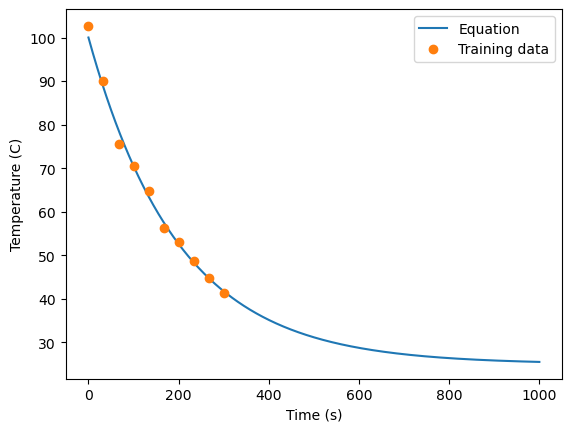

In [3]:
np.random.seed(10)
tf.random.set_seed(0)

Tenv = 25
T0 = 100
R = 0.005
times = np.linspace(0, 1000, 1000)
eq = functools.partial(cooling_law, Tenv=Tenv, T0=T0, R=R)
temps = eq(times)

# Make training data
t = np.linspace(0, 300, 10)
T = eq(t) +  2 * np.random.randn(10)

plt.plot(times, temps)
plt.plot(t, T, 'o')
plt.legend(['Equation', 'Training data'])
plt.ylabel('Temperature (C)')
plt.xlabel('Time (s)')

First, we will look at what happens if we train a simple neural network (a fully connected multi-layer perceptron with ReLU activations). The code below creates an MLP using Keras, along with a training function that we will reuse for all of the networks in this notebook. The training function minimizes the mean squared error on the training data, and can optionally add a second, physics-based loss term (we will use this for the physics-informed networks below).

In [4]:
def make_mlp(n_units=100):
    """A fully-connected MLP that maps time t to temperature T(t)."""
    return tf.keras.Sequential([
        tf.keras.layers.Dense(n_units, activation="relu", input_shape=(1,)),
        tf.keras.layers.Dense(n_units, activation="relu"),
        tf.keras.layers.Dense(n_units, activation="relu"),
        tf.keras.layers.Dense(n_units, activation="relu"),
        tf.keras.layers.Dense(1),
    ])

def train(model, t, T, epochs=5000, lr=1e-4, physics_loss=None,
          physics_weight=1.0, extra_variables=None):
    """Train with MSE loss on (t, T), plus an optional physics loss term."""
    Xt = tf.constant(t.reshape(-1, 1), tf.float32)
    yt = tf.constant(T.reshape(-1, 1), tf.float32)
    # extra_variables lets us learn parameters that are not network weights
    # (we will use this to learn the cooling rate r later on)
    variables = model.trainable_variables + (extra_variables or [])
    optimizer = tf.keras.optimizers.Adam(lr)

    @tf.function
    def train_step():
        with tf.GradientTape() as tape:
            loss = tf.reduce_mean((yt - model(Xt, training=True)) ** 2)
            if physics_loss is not None:
                loss += physics_weight * physics_loss(model)
        grads = tape.gradient(loss, variables)
        optimizer.apply_gradients(zip(grads, variables))
        return loss

    losses = []
    for ep in range(epochs):
        losses.append(float(train_step()))
        if ep % int(epochs / 10) == 0:
            print(f"Epoch {ep}/{epochs}, loss: {losses[-1]:.2f}")
    return losses

We will first train the neural network with mean squared error (MSE) loss. The input for our network here is the 10 times that we measured our cup of coffee $t$, and the output here are the 10 temperatures that we measured at those times.

![vanilla](images/Vanilla_NN.png) Image credit: <a href="https://benmoseley.blog/my-research/so-what-is-a-physics-informed-neural-network/">B. Moseley </a>

Because the neural network acts as a univeral function approximator, we will denote the neural network as $f(t|\theta)$. That is, it takes in the time $t$ and maps this to a prediction for the temperature, given the values of the weights of the neural network $\theta$.

MSE loss for the 10 data points is calculated by
\begin{equation}
Loss_{MSE} = \frac{1}{10}\sum_{j=0}^{10} (f(t_{j}|\theta)-T_{j})^2
\end{equation}

The code below trains the MLP for 5000 epochs.

Epoch 0/5000, loss: 6235.81


Epoch 500/5000, loss: 2266.53
Epoch 1000/5000, loss: 307.11


Epoch 1500/5000, loss: 12.85
Epoch 2000/5000, loss: 1.21


Epoch 2500/5000, loss: 0.45
Epoch 3000/5000, loss: 0.44


Epoch 3500/5000, loss: 0.81


Epoch 4000/5000, loss: 0.33


Epoch 4500/5000, loss: 0.43


Text(0.5, 0, 'Epoch')

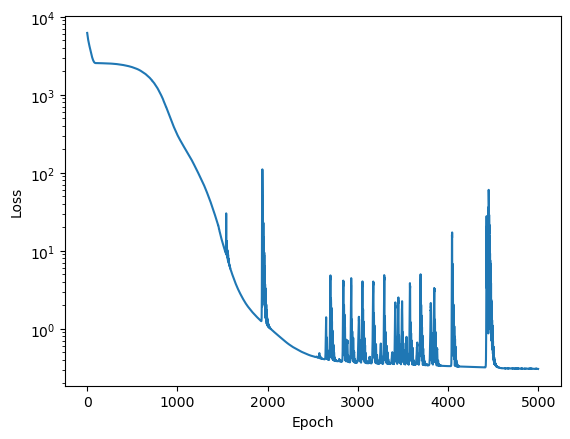

In [5]:
net = make_mlp()
losses = train(net, t, T, epochs=5000, lr=1e-4)

plt.plot(losses)
plt.yscale('log')
plt.ylabel("Loss")
plt.xlabel("Epoch")

Now let's look at how well the trained neural network does. We first use the trained neural network to predict the temperature of our cup of coffee over the entire 1000 seconds in our data set. The code below does inference with the trained neural network to give us predictions for the temperature.

In [6]:
preds = net.predict(times.reshape(-1, 1), verbose=0)

Now, let's plot the predictions of the neural network and compare it with the true equation for the temperature of the cup of coffee.

Text(0.5, 0, 'Time (s)')

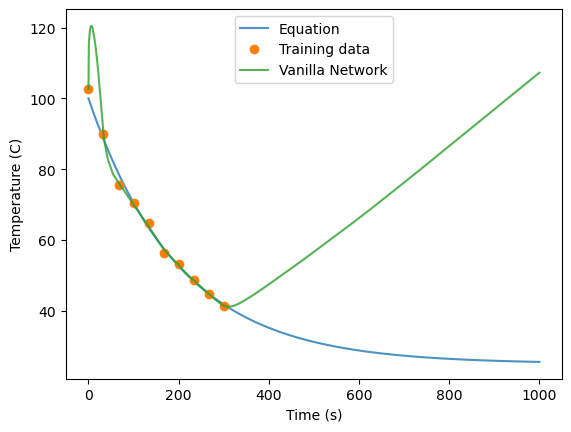

In [7]:
plt.plot(times, temps, alpha=0.8)
plt.plot(t, T, 'o')
plt.plot(times, preds, alpha=0.8)

plt.legend(labels=['Equation','Training data', 'Vanilla Network'])
plt.ylabel('Temperature (C)')
plt.xlabel('Time (s)')

As can be seen, the neural network does a decent job of predicting the temperature of the cup of coffee for the first 300 seconds, but it does a very poor job extrapolating to future times (t>300 seconds) because the neural network has no physical constraints on its prediction. It also is not quite sure how to handle the initial points.

![PINN](images/PINN.png) Image credit: <a href="https://benmoseley.blog/my-research/so-what-is-a-physics-informed-neural-network/">B. Moseley </a>

Next, we will look at how to use a physics-informed neural network instead. The idea behind PINN's is that we can impose a physical constraint on our neural network prediction, given our prior physical knowledge about the system. To do this, we will use what are called collocation points. Collocation points are points that we will evaluate our network at during the training process to ensure that the neural network prediction will be consistent with our known prior physical knowledge.

In this case, our prior physical knowledge is Newton's cooling law, so we can write this constraint as
\begin{equation}
g(t,T) = \frac{dT(t)}{dt} - r(T_{env}-T(t)) = 0
\end{equation}.

We can use Newton's cooling law to write a physics loss term for the data as

\begin{equation}
g(t,f(t|\theta)) = \frac{df(t|\theta)}{dt} - r(T_{env}-f(t|\theta))
\end{equation}
where we have just replaced the temperature with the prediction from our neural network.

We will then evaluate this physics loss term at $M = 1000$ collocation points. Our physics loss term is
\begin{equation}
Loss_{physics} = \frac{1}{M}\sum_{i=0}^{M} \left(\frac{df(t_{i}|\theta)}{dt_{i}} - r(T_{env}-f(t_{i}|\theta))\right)^2
\end{equation}.

In order to evalute this term, we need to take the derivative of our neural network as its being trained. We can use automatic differentiation to do this.

![AD](images/AD_Baydin2015.png)

The above figure comes from <a href="https://arxiv.org/abs/1502.05767">Baydin et al. 2015 </a>.

TensorFlow uses *tf.GradientTape* to do automatic differentiation: operations executed inside the tape's context are recorded, and the tape can then compute the gradient of any recorded output with respect to any recorded input. We already use one tape inside our training function to get the gradients of the loss with respect to the network weights $\theta$. For the physics loss we open a second, nested tape that instead differentiates the network output with respect to its *input* $t$, giving us $df(t|\theta)/dt$ at the collocation points. (PyTorch and JAX have equivalent functionality: *torch.autograd.grad* and *jax.grad*.)

In [8]:
# make M = 1000 collocation points
ts_colloc = tf.reshape(tf.linspace(0.0, 1000.0, 1000), (-1, 1))

def physics_loss(model):
    """The physics loss of the model"""
    with tf.GradientTape() as tape:
        # watch the collocation points so we can differentiate wrt the input times
        tape.watch(ts_colloc)
        # run the collocation points through the network
        temps = model(ts_colloc)
    # get the gradient dT/dt
    dT = tape.gradient(temps, ts_colloc)
    # compute the ODE
    ode = dT - R * (Tenv - temps)
    # MSE of ODE
    return tf.reduce_mean(ode ** 2)

Now that we have the physics loss function, we will train the model with both the MSE loss term and the physics loss term. The training objective is now to minimize this loss function:
\begin{equation}
Loss_{MSE}+\lambda Loss_{physics}
\end{equation}
where $\lambda$ is a hyperparameter that weighs the second loss term. Here we will choose $\lambda$=1. We will again train the network for 5000 epochs, but now training for both loss terms.

Epoch 0/5000, loss: 4734.83


Epoch 500/5000, loss: 2076.26


Epoch 1000/5000, loss: 125.53


Epoch 1500/5000, loss: 2.93


Epoch 2000/5000, loss: 1.12


...

Epoch 3000/5000, loss: 1.02


Epoch 3500/5000, loss: 1.37


Epoch 4000/5000, loss: 0.88


Epoch 4500/5000, loss: 0.87


Text(0.5, 0, 'Epoch')

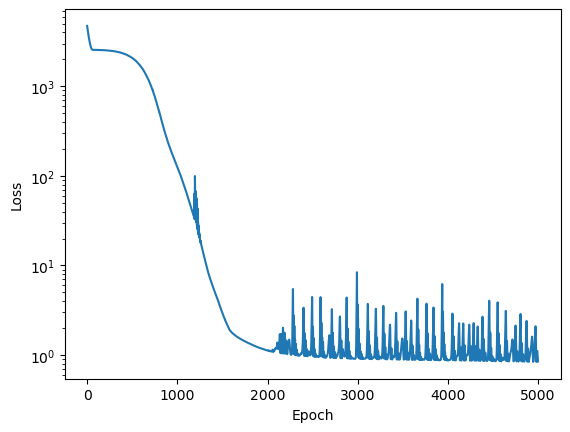

In [9]:
netpinn = make_mlp()
losses = train(netpinn, t, T, epochs=5000, lr=1e-4,
               physics_loss=physics_loss, physics_weight=1.0)

plt.plot(losses)
plt.yscale('log')
plt.ylabel("Loss")
plt.xlabel("Epoch")

Now that the model is trained, we will look at the predictions from the PINN model.

Text(0.5, 0, 'Time (s)')

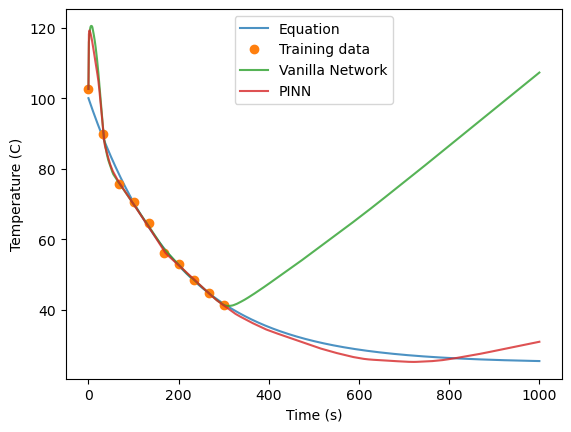

In [10]:
predspinn = netpinn.predict(times.reshape(-1, 1), verbose=0)

plt.plot(times, temps, alpha=0.8)
plt.plot(t, T, 'o')
plt.plot(times, preds, alpha=0.8)
plt.plot(times, predspinn, alpha=0.8)
plt.legend(labels=['Equation','Training data', 'Vanilla Network', 'PINN'])
plt.ylabel('Temperature (C)')
plt.xlabel('Time (s)')

The PINN performs much better than the original Vanilla network that was trained without any physics constraint.

Next, we will look at how we can use the PINN to learn unknown parameters in our model. For example, if we did not know the parameter $r$ in our differential equation, how can we use a PINN to estimate what it is?

Recall that Newton's law of cooling is
\begin{equation}
\frac{dT(t)}{dt} = r(T_{env}-T(t))
\end{equation}
where $T(t)$ is the temperature of our cup of coffee at time t, $T_{env}$ is the temperature of the ambient environment, and $r$ is the cooling rate.

To add $r$ as a differentiable parameter that will be learned along with the weights of the network, we define it as a *tf.Variable*, which means that it is differentiable and can be updated by the optimizer. We pass it to our training function through the `extra_variables` argument, so that the optimizer updates it alongside the network weights. To update the physics loss term, we use the current value of the $r$ parameter, rather than the known value of $r$ (recall that we used $r=0.005$ when we created our data set).

In [11]:
r_learned = tf.Variable(0.0)

def physics_loss_discovery(model):
    with tf.GradientTape() as tape:
        tape.watch(ts_colloc)
        # run the collocation points through the network
        temps = model(ts_colloc)
    # get the gradient
    dT = tape.gradient(temps, ts_colloc)
    # compute the ODE
    # note that here we now use r_learned rather than R because this
    # parameter will be updated as the model is trained
    ode = r_learned * (Tenv - temps) - dT
    # MSE of ODE
    return tf.reduce_mean(ode ** 2)

Now we will train the network with this updated loss function. The network will learn how to predict the temperature, given the time, and the current value for $r$.

One subtlety: the discovery problem has a trivial solution that the optimizer can fall into — if the network predicts a flat temperature outside the training data, then $dT/dt \approx 0$ there, and the physics loss can be minimized by simply driving $r$ to zero. Weighting the physics term more heavily (here we use $\lambda=10$) and training for longer pushes the optimizer away from this trivial solution, so that the network has to find an $r$ consistent with the trend in the observed data.

Epoch 0/10000, loss: 3731.03


Epoch 1000/10000, loss: 83.19


Epoch 2000/10000, loss: 7.35


Epoch 3000/10000, loss: 6.12


Epoch 4000/10000, loss: 5.14


...

Epoch 6000/10000, loss: 11.41


Epoch 7000/10000, loss: 3.27


Epoch 8000/10000, loss: 2.07


Epoch 9000/10000, loss: 1.10


Text(0.5, 0, 'Epoch')

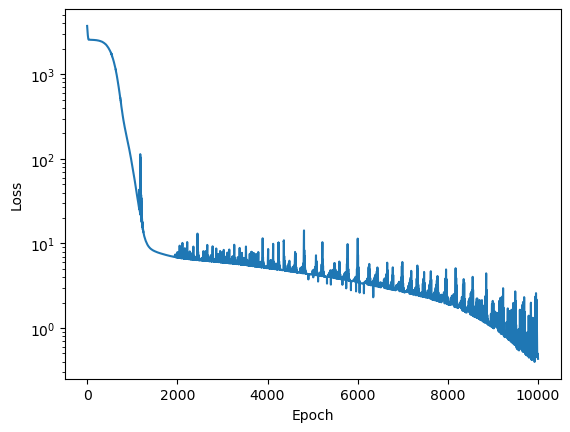

In [12]:
netdisc = make_mlp()
losses = train(netdisc, t, T, epochs=10000, lr=1e-4,
               physics_loss=physics_loss_discovery, physics_weight=10.0,
               extra_variables=[r_learned])

plt.plot(losses)
plt.yscale('log')
plt.ylabel("Loss")
plt.xlabel("Epoch")

Similar to before, we will use the trained model to predict the temperature over the entire range of values.

Now we can look at how the prediction compares against our previous models and the true values. Even though the model had to learn the $r$ parameter along with the functional dependence of Temperature as a function of time, the predictions are on par with the predictions of the PINN model where we used the cooling rate that we knew in the physics loss function.

Text(0.5, 0, 'Time (s)')

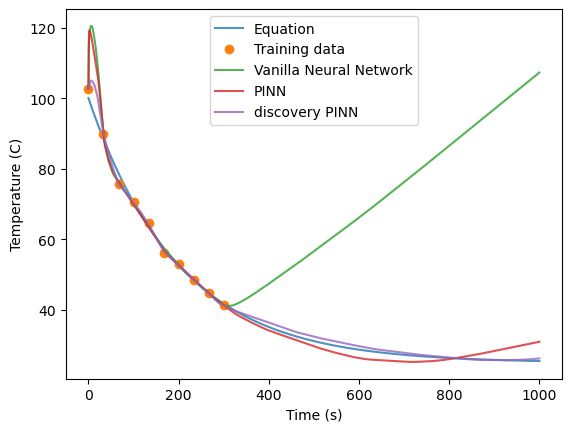

In [13]:
predspinndiscover = netdisc.predict(times.reshape(-1, 1), verbose=0)

plt.plot(times, temps, alpha=0.8)
plt.plot(t, T, 'o')
plt.plot(times, preds, alpha=0.8)
plt.plot(times, predspinn, alpha=0.8)
plt.plot(times, predspinndiscover, alpha=0.8)
plt.legend(labels=['Equation','Training data', 'Vanilla Neural Network','PINN','discovery PINN'])
plt.ylabel('Temperature (C)')
plt.xlabel('Time (s)')

Finally we can look at the value that was learned by the network for $r$. This just requires the following code:

In [14]:
print(float(r_learned))

0.004693947732448578


Our model found a value very close to the real value $r=0.005$.

A great resource for more complex applications of PINN's is <a href="https://arxiv.org/abs/2308.08468">Wang et al. 2023 </a>.

## Neural Ordinary Differential Equations (NODE's)

Another way that we can include physics in our machine learning model is through using neural ordinary differential equations (NODE's). NODE's were introduced in <a href="https://arxiv.org/abs/1806.07366">Chen et al. 2018</a>, and use neural networks to learn an unknown function that is the derivative of an observed quantity. That is, we can use a neural network to parameterize the function $f(h(t), t, \theta)$, where $f(h(t), t, \theta)$ is the derivative of a function $h(t)$:
\begin{equation}
\frac{dh(t)}{dt} = f(h(t),t,\theta)
\end{equation}

To learn the unknown function $f(h(t), t, \theta)$, which is parameterized as a neural network with weights $\theta$, we can perform back-propogation through typical numerical ODE solvers.

We'll continue with the example of Newton's Law of Cooling, and create a NODE model trained on observed temperature points to then predict future states of the system. In this case, we do not directly include the physical law function (as we did with PINN's), but we use neural ODE's to learn the function $dT/dt$.

![AD](images/RNNvsNODE.png)

We'll start by parameterizing the temperature derivative as a neural network. The model below is an MLP that will be used to learn the temperature derivative as an unknown function. It takes in the current temperature (normalized to the expected temperature range) and outputs the current rate of change of the temperature.

In [15]:
def make_dTdt(n_units=100):
    """An MLP that maps the current temperature T to its derivative dT/dt."""
    out_init = tf.keras.initializers.RandomNormal(mean=0.0, stddev=0.5)
    return tf.keras.Sequential([
        # do the normalization here (temperatures span roughly 0-105 C)
        tf.keras.layers.Rescaling(1.0 / 105.0, input_shape=(1,)),
        tf.keras.layers.Dense(n_units, activation="relu"),
        tf.keras.layers.Dense(n_units, activation="relu"),
        tf.keras.layers.Dense(n_units, activation="relu"),
        tf.keras.layers.Dense(1, kernel_initializer=out_init,
                              bias_initializer="ones"),
    ])

We then need to numerically integrate the function that we are learning. For PyTorch and JAX there are libraries that provide differentiable ODE solvers (*torchdiffeq*, from Chen et al. 2018, and *diffrax*). Here we instead write our own small fixed-step integrator directly in TensorFlow, using the classical Runge-Kutta 4th order method ("RK4"). Because each integration step is built out of ordinary differentiable TensorFlow operations, gradients can flow through the entire integration — this is all we need to be able to train the network.

In [16]:
def rk4_integrate(f, y0, ts):
    """Integrate dy/dt = f(y) with one RK4 step per interval in ts.

    f  - a function (here, a neural network) giving the derivative dy/dt
    y0 - the initial value of the temperature
    ts - the times we want the solution at
    """
    ys = [y0]
    y = y0
    for i in range(len(ts) - 1):
        h = ts[i + 1] - ts[i]
        k1 = f(y)
        k2 = f(y + h / 2 * k1)
        k3 = f(y + h / 2 * k2)
        k4 = f(y + h * k3)
        y = y + h / 6 * (k1 + 2 * k2 + 2 * k3 + k4)
        ys.append(y)
    return tf.concat(ys, axis=0)

Recall that an ODE initial value problem has the form
\begin{equation}
\frac{dy}{dt} = f(y(t),t,\theta),\quad y(0) = y_{0}
\end{equation}

We'll give the initial temperature point $T_{0}$ to our NODE model, along with a vector of integration times. Then we will optimize the NODE model against the 10 observed temperature points, in order to learn the optimal parameters $\theta$ for the neural network parameterizing dTdt.

In [17]:
num_iterations = 4000

dTdt = make_dTdt()
optimizer = tf.keras.optimizers.experimental.AdamW(1e-4)

# The observed temperatures, the time points we integrate over,
# and the initial observed temperature
yt = tf.constant(T.reshape(-1, 1), tf.float32)
inttimes = [float(ti) for ti in t]
Temp0 = tf.constant([[T[0]]], tf.float32)

@tf.function
def node_step():
    with tf.GradientTape() as tape:
        Temps = rk4_integrate(dTdt, Temp0, inttimes)
        # We'll use MSE loss here.
        loss = tf.reduce_mean((Temps - yt) ** 2)
    grads = tape.gradient(loss, dTdt.trainable_variables)
    optimizer.apply_gradients(zip(grads, dTdt.trainable_variables))
    return loss

losses = []
for itr in range(num_iterations):
    losses.append(float(node_step()))
    if itr % int(num_iterations / 10) == 0:
        print(f"Epoch {itr}/{num_iterations}, loss: {losses[-1]:.2f}")

Epoch 0/4000, loss: 89136.54


Epoch 400/4000, loss: 24.21


Epoch 800/4000, loss: 19.12


Epoch 1200/4000, loss: 17.53


Epoch 1600/4000, loss: 15.96


Epoch 2000/4000, loss: 14.26


Epoch 2400/4000, loss: 12.36


Epoch 2800/4000, loss: 10.29


Epoch 3200/4000, loss: 8.14


Epoch 3600/4000, loss: 6.06


Text(0.5, 0, 'Epoch')

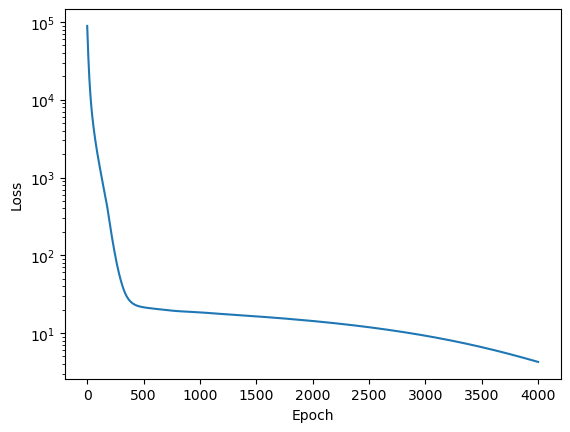

In [18]:
plt.plot(losses)
plt.yscale("log")
plt.ylabel("Loss")
plt.xlabel("Epoch")

Now that the model is trained, we integrate the learned derivative forward from the initial temperature over the full 1000 seconds, and compare against our previous models.

Text(0.5, 0, 'Time (s)')

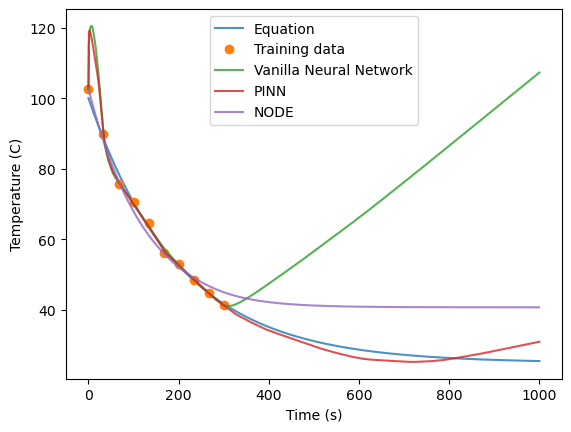

In [19]:
extraptimes = np.arange(0, 1000).astype(float)
extrapTemps = rk4_integrate(dTdt, Temp0, extraptimes)

plt.plot(times, temps, alpha=0.8)
plt.plot(t, T, 'o')
plt.plot(times, preds, alpha=0.8)
plt.plot(times, predspinn, alpha=0.8)
plt.plot(extraptimes, extrapTemps[:, 0], alpha=0.8)
plt.legend(labels=['Equation','Training data', 'Vanilla Neural Network','PINN','NODE'])
plt.ylabel('Temperature (C)')
plt.xlabel('Time (s)')

The NODE model doesn't do quite as well as the PINN's — its prediction levels off around 41 $^{\circ}C$ rather than continuing to decay to room temperature — but it does significantly better than the vanilla neural network. Recall that we have not explicitly included any physical constraint here, except the assumption that our observed temperature observations are the result of integrating a continous function.

Since we have learned the derivative $dT/dt$ here, we can also look at the functional dependence of the trained neural network to try to better understand the properties of this function. In cases where we don't have a prior physical constraint on this function, or only have partial physical understanding of this function, NODE's can be powerful tools to improve predictions and to potentially even to learn unknown physics by optimizing against observations.

Text(0, 0.5, 'Learned dT/dt')

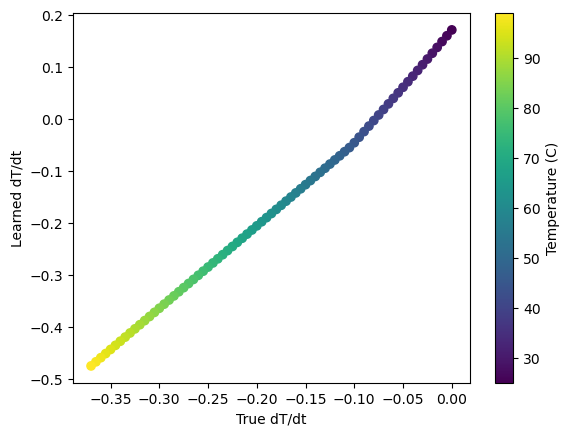

In [20]:
r = 0.005
Tenv = 25

dTdtreal = []
dTdtnode = []
Temperatures = np.arange(25, 100, 1)

for Tcurr in Temperatures:
    dT = dTdt(tf.constant([[float(Tcurr)]]))
    dTdtreal.append(r * (Tenv - Tcurr))
    dTdtnode.append(float(dT))

plt.scatter(dTdtreal, dTdtnode, c=Temperatures)
plt.colorbar(label='Temperature (C)')
plt.xlabel('True dT/dt')
plt.ylabel('Learned dT/dt')

Over the range of temperatures covered by the training data (roughly 41-100 $^{\circ}C$), the learned derivative closely follows the true cooling law $dT/dt = r(T_{env}-T)$ — the network has recovered the underlying physics directly from the 10 noisy observations. Below the coldest observed temperature, however, the learned derivative bends away from the true law and crosses zero near 41 $^{\circ}C$ — which is exactly why the NODE's prediction flattens out there instead of decaying all the way to room temperature. Like the vanilla network, the learned derivative is only trustworthy where data constrained it.